<a href="https://colab.research.google.com/github/d2535358-web/Mini-Project/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐦 Twitter Sentiment Analysis
### Classifying Public Opinion: Positive | Negative | Neutral
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from wordcloud import WordCloud
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 1. Load the Dataset

In [ ]:
col_names = ['ID', 'Entity', 'Sentiment', 'Text']
train_df = pd.read_csv('/content/twitter_training.csv', header=None, names=col_names)
val_df = pd.read_csv('/content/twitter_validation.csv', header=None, names=col_names)

print(f'Training set  : {train_df.shape[0]:,} rows')
print(f'Validation set: {val_df.shape[0]:,} rows')
train_df.head(10)

Training set  : 74,682 rows
Validation set: 1,000 rows


,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


## 2. Exploratory Data Analysis

In [ ]:
print('=== Training Set Info ===')
print(train_df.info())
print('\n=== Missing Values ===')
print(train_df.isnull().sum())
print('\n=== Sentiment Distribution ===')
print(train_df['Sentiment'].value_counts())

=== Training Set Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

=== Missing Values ===
ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

=== Sentiment Distribution ===
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


### Filter to 3 Sentiment Classes
We focus on **Positive**, **Negative**, and **Neutral** - dropping *Irrelevant* tweets.

In [ ]:
train_df = train_df[train_df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])].copy()
val_df = val_df[val_df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])].copy()

train_df.dropna(subset=['Text'], inplace=True)
val_df.dropna(subset=['Text'], inplace=True)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

print(f'Training set after filtering: {train_df.shape[0]:,}')
print(f'Validation set after filtering: {val_df.shape[0]:,}')
print('\nSentiment Distribution (Training):')
print(train_df['Sentiment'].value_counts())

Training set after filtering: 61,121
Validation set after filtering: 828

Sentiment Distribution (Training):
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


### Sentiment Distribution

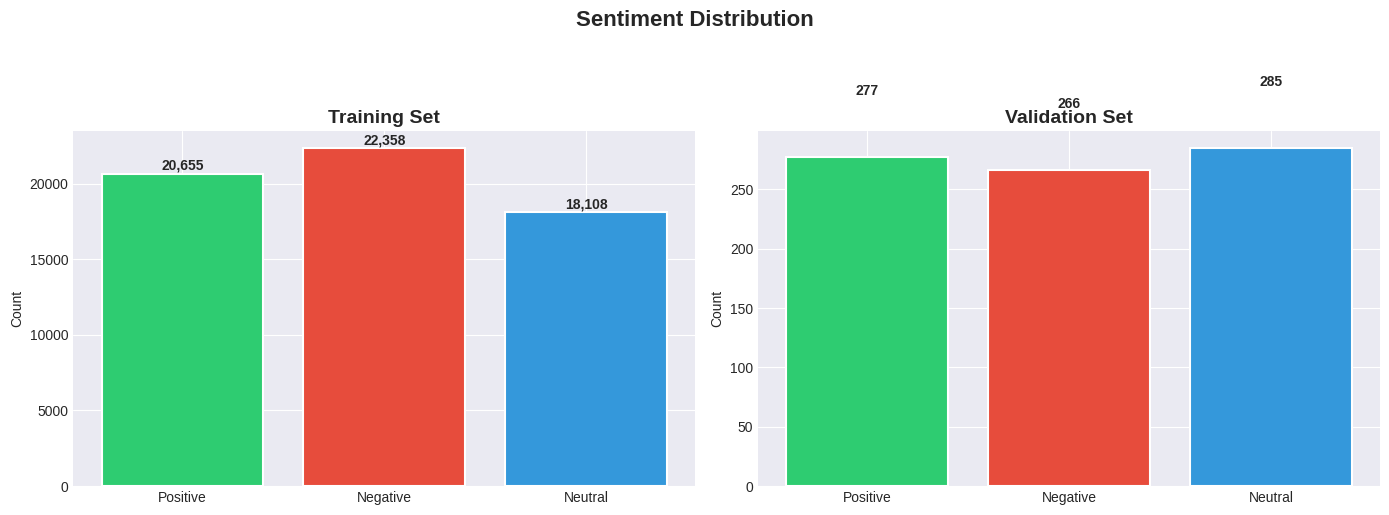

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for ax, df, title in zip(axes, [train_df, val_df], ['Training Set', 'Validation Set']):
    counts = df['Sentiment'].value_counts()
    order = ['Positive', 'Negative', 'Neutral']
    vals = [counts.get(s, 0) for s in order]
    bars = ax.bar(order, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Sentiment Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Top Entities by Tweet Count

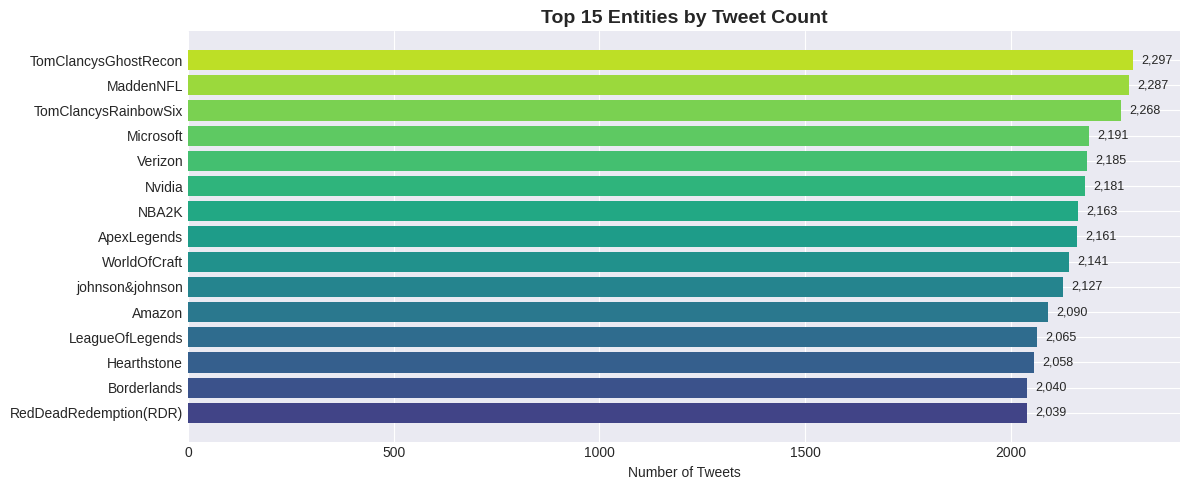

In [ ]:
top_entities = train_df['Entity'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_entities.index[::-1], top_entities.values[::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)))
ax.set_xlabel('Number of Tweets')
ax.set_title('Top 15 Entities by Tweet Count', fontsize=14, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2.,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

### Sentiment Breakdown per Entity (Top 10)

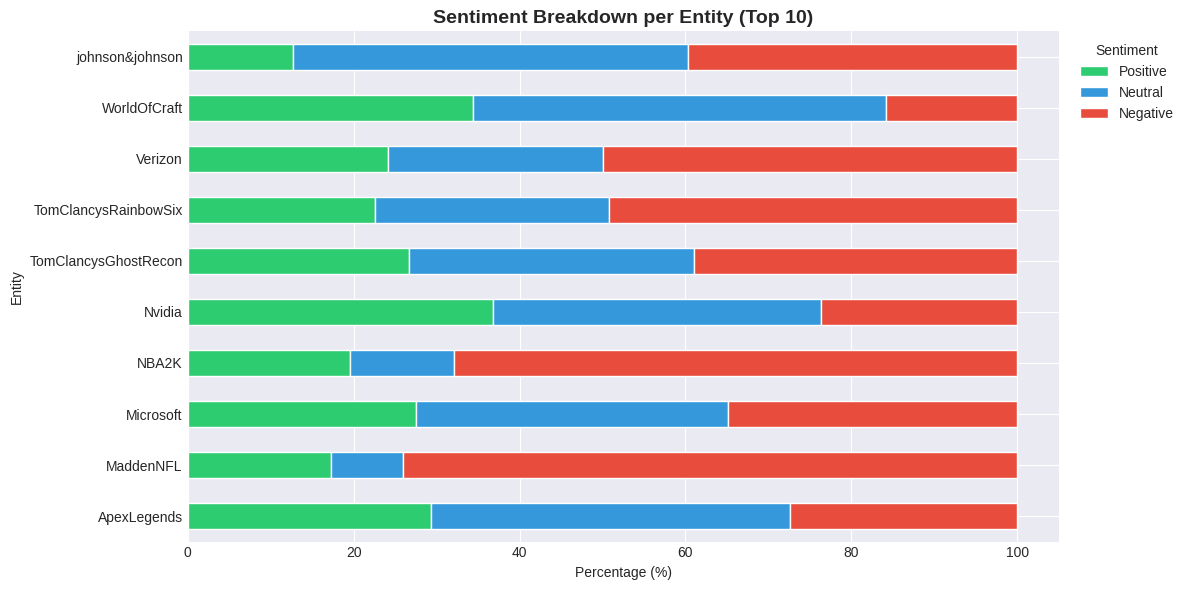

In [ ]:
top10 = train_df['Entity'].value_counts().head(10).index
subset = train_df[train_df['Entity'].isin(top10)]
ct = pd.crosstab(subset['Entity'], subset['Sentiment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
ct[['Positive','Neutral','Negative']].plot(kind='barh', stacked=True, ax=ax,
    color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white')
ax.set_xlabel('Percentage (%)')
ax.set_title('Sentiment Breakdown per Entity (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('sentiment_per_entity.png', dpi=150, bbox_inches='tight')
plt.show()

### Tweet Length Analysis

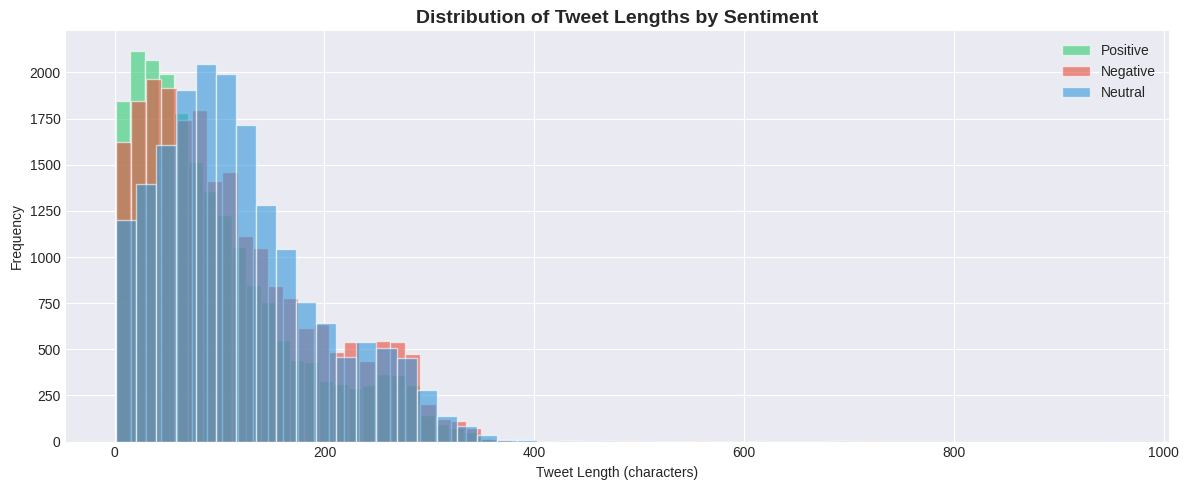

             count   mean   std  min   25%    50%    75%    max
Sentiment                                                      
Negative   22358.0  111.3  81.9  1.0  46.0   91.0  161.0  727.0
Neutral    18108.0  118.8  77.4  1.0  62.0  105.0  161.0  957.0
Positive   20655.0   95.9  77.4  1.0  36.0   74.0  134.0  692.0


In [ ]:
train_df['text_length'] = train_df['Text'].astype(str).apply(len)

fig, ax = plt.subplots(figsize=(12, 5))
for sent, color in zip(['Positive','Negative','Neutral'], ['#2ecc71','#e74c3c','#3498db']):
    subset = train_df[train_df['Sentiment'] == sent]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, label=sent, color=color, edgecolor='white')
ax.set_xlabel('Tweet Length (characters)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Tweet Lengths by Sentiment', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('tweet_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df.groupby('Sentiment')['text_length'].describe().round(1))

## 3. Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'pic\.twitter\.com/\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

train_df['clean_text'] = train_df['Text'].apply(clean_text)
val_df['clean_text'] = val_df['Text'].apply(clean_text)

train_df = train_df[train_df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)
val_df = val_df[val_df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

print('Preprocessing complete!')
print(f'Training: {len(train_df):,} | Validation: {len(val_df):,}')
train_df[['Text','clean_text','Sentiment']].head(10)

Preprocessing complete!
Training: 59,580 | Validation: 827


,Text,clean_text,Sentiment
0,im getting on borderlands and i will murder yo...,getting borderland murder,Positive
1,I am coming to the borders and I will kill you...,coming border kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderland kill,Positive
3,im coming on borderlands and i will murder you...,coming borderland murder,Positive
4,im getting on borderlands 2 and i will murder ...,getting borderland murder,Positive
5,im getting into borderlands and i can murder y...,getting borderland murder,Positive
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...,Positive
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know huge...,Positive
8,So I spent a few hours doing something for fun...,spent hour something fun dont know huge border...,Positive
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...,Positive


### Word Clouds by Sentiment

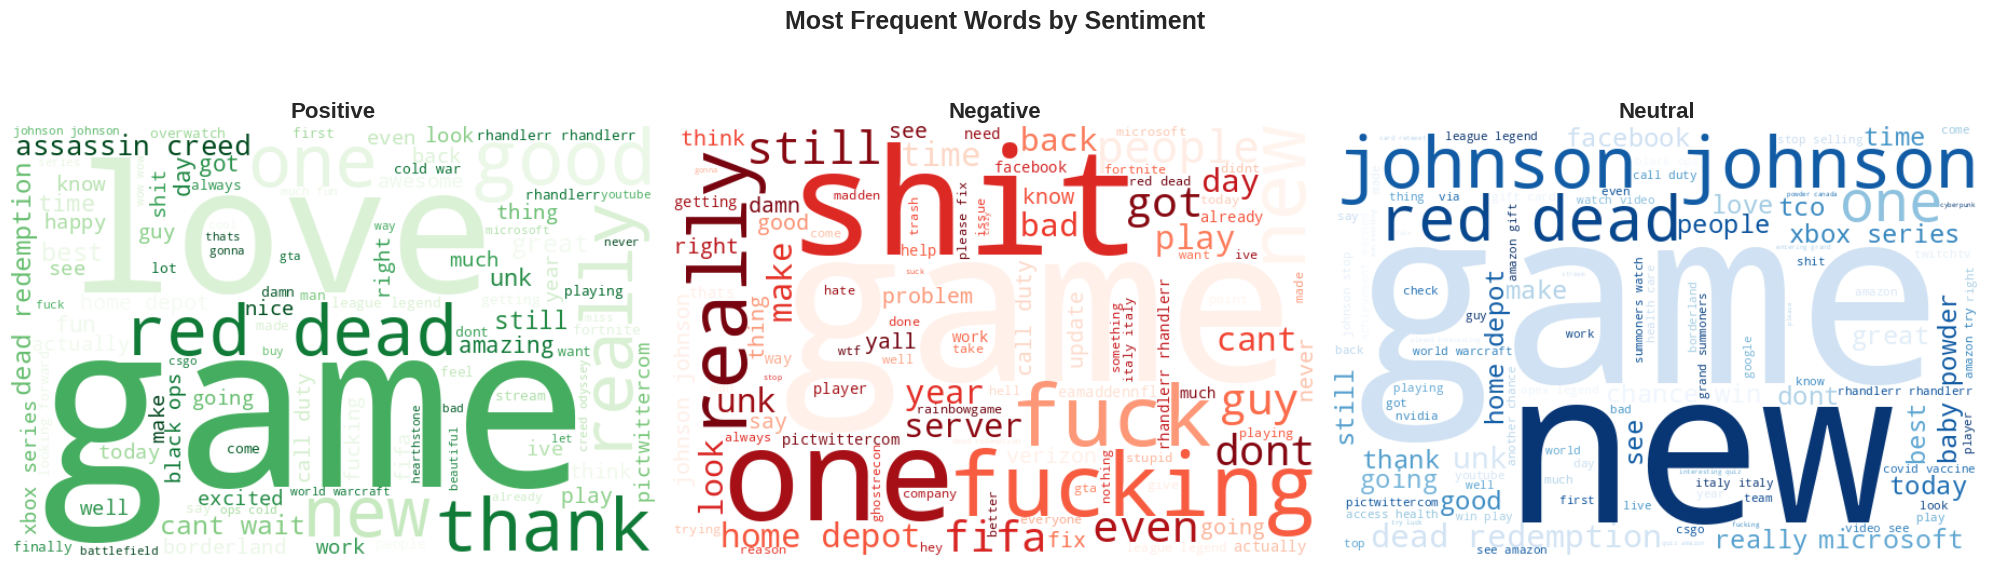

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sentiments = ['Positive', 'Negative', 'Neutral']
cmaps = ['Greens', 'Reds', 'Blues']

for ax, sent, cmap in zip(axes, sentiments, cmaps):
    text = ' '.join(train_df[train_df['Sentiment'] == sent]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100, contour_width=1).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sent, fontsize=16, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 15 Words per Sentiment

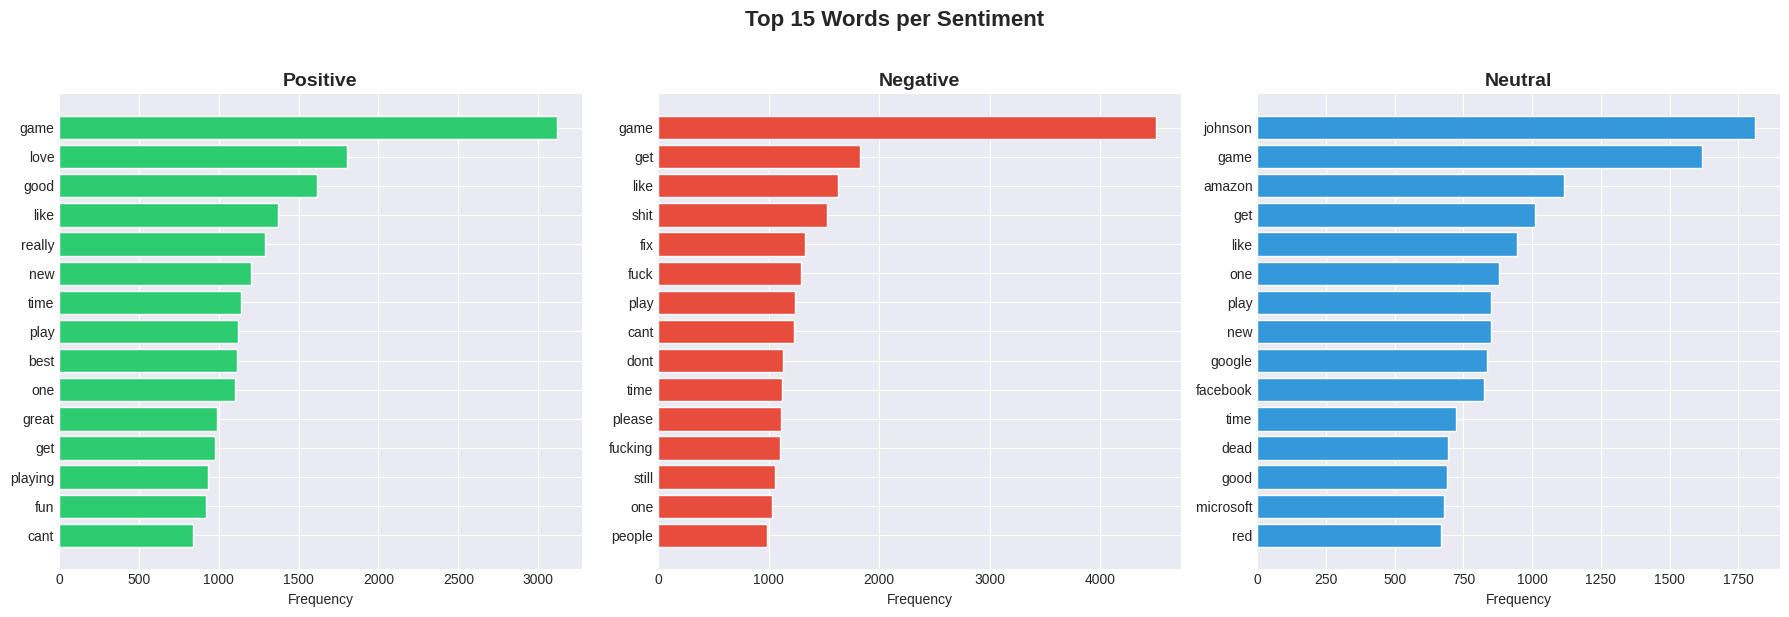

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_map = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}

for ax, sent in zip(axes, ['Positive', 'Negative', 'Neutral']):
    words = ' '.join(train_df[train_df['Sentiment'] == sent]['clean_text']).split()
    common = Counter(words).most_common(15)
    w, c = zip(*common)
    ax.barh(list(w)[::-1], list(c)[::-1], color=colors_map[sent], edgecolor='white')
    ax.set_title(f'{sent}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words per Sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Extraction (TF-IDF)

In [ ]:
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, max_df=0.95)

X_train = tfidf.fit_transform(train_df['clean_text'])
X_val = tfidf.transform(val_df['clean_text'])

y_train = train_df['Sentiment']
y_val = val_df['Sentiment']

print(f'TF-IDF Training matrix : {X_train.shape}')
print(f'TF-IDF Validation matrix: {X_val.shape}')

TF-IDF Training matrix : (59580, 15000)
TF-IDF Validation matrix: (827, 15000)


## 5. Model Training & Comparison

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = {'accuracy': acc, 'predictions': y_pred, 'model': model}
    print(f'  {name}: {acc:.4f} accuracy\n')

Training Logistic Regression...
  Logistic Regression: 0.9226 accuracy

Training Multinomial Naive Bayes...
  Multinomial Naive Bayes: 0.8694 accuracy

Training Linear SVM...
  Linear SVM: 0.9528 accuracy

Training Random Forest...
  Random Forest: 0.8174 accuracy



### Model Accuracy Comparison

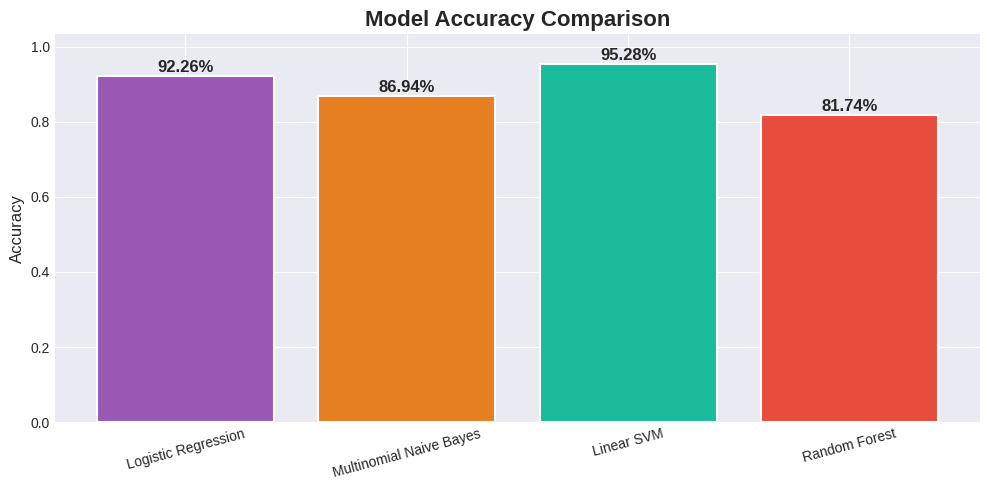

In [ ]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_ylim(0, max(accuracies) + 0.08)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Best Model - Detailed Classification Report

In [ ]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_preds = results[best_name]['predictions']
print(f'Best Model: {best_name} (Accuracy: {results[best_name]["accuracy"]:.4f})\n')
print(classification_report(y_val, best_preds, digits=4))

Best Model: Linear SVM (Accuracy: 0.9528)

              precision    recall  f1-score   support

    Negative     0.9444    0.9623    0.9533       265
     Neutral     0.9780    0.9368    0.9570       285
    Positive     0.9366    0.9603    0.9483       277

    accuracy                         0.9528       827
   macro avg     0.9530    0.9531    0.9529       827
weighted avg     0.9534    0.9528    0.9529       827



### Confusion Matrix (Best Model)

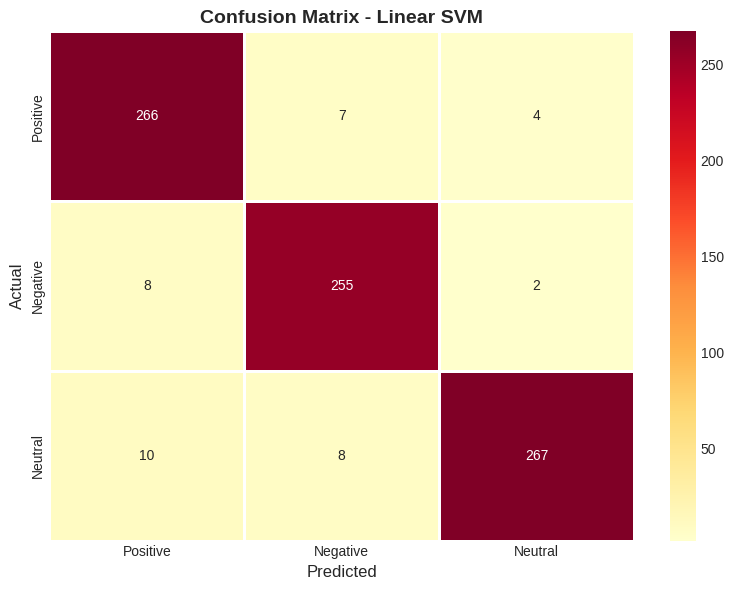

In [ ]:
labels = ['Positive', 'Negative', 'Neutral']
cm = confusion_matrix(y_val, best_preds, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=labels,
            yticklabels=labels, linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Public Opinion Trends Visualization

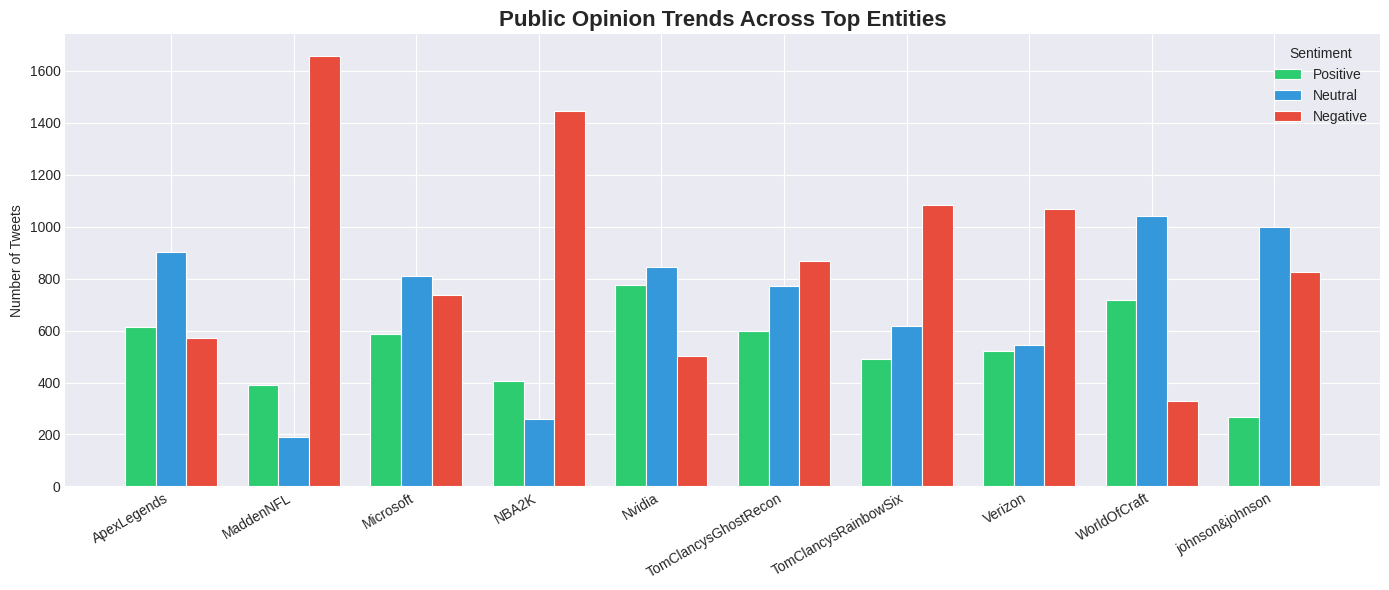

In [ ]:
top_entities = train_df['Entity'].value_counts().head(10).index
subset = train_df[train_df['Entity'].isin(top_entities)]
sentiment_counts = subset.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sentiment_counts.index))
width = 0.25

for i, (sent, color) in enumerate(zip(['Positive','Neutral','Negative'],
                                       ['#2ecc71','#3498db','#e74c3c'])):
    if sent in sentiment_counts.columns:
        ax.bar(x + i*width, sentiment_counts[sent], width, label=sent,
               color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(sentiment_counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of Tweets')
ax.set_title('Public Opinion Trends Across Top Entities', fontsize=16, fontweight='bold')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('opinion_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### Sentiment Ratio Heatmap

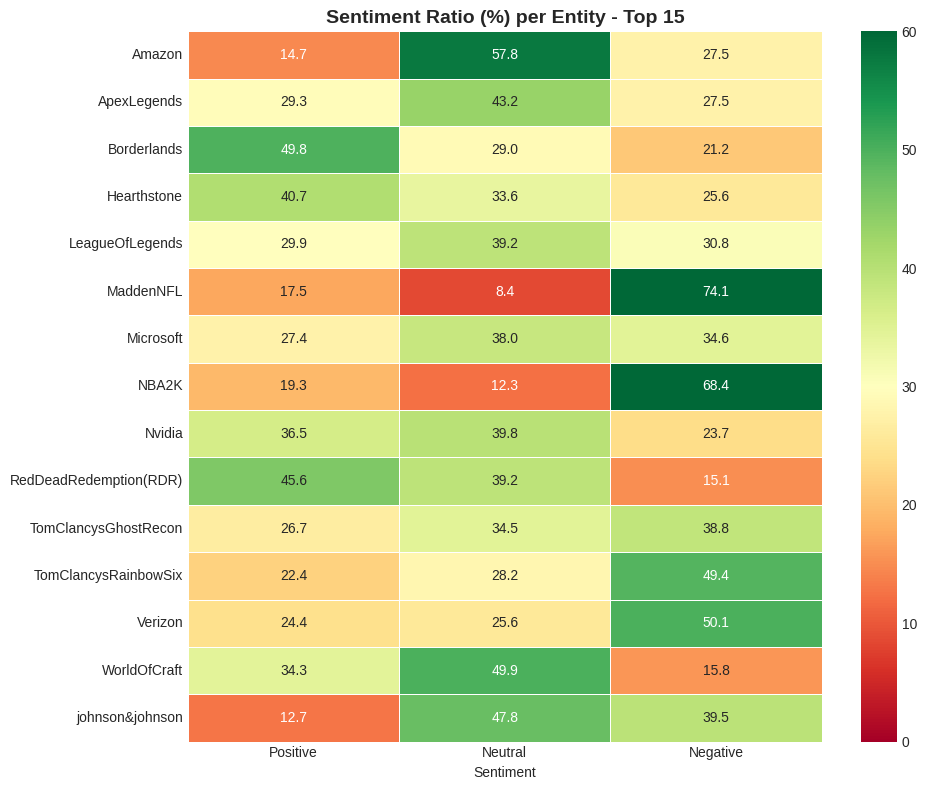

In [ ]:
top15 = train_df['Entity'].value_counts().head(15).index
subset = train_df[train_df['Entity'].isin(top15)]
ratio = pd.crosstab(subset['Entity'], subset['Sentiment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ratio[['Positive','Neutral','Negative']], annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=0, vmax=60)
ax.set_title('Sentiment Ratio (%) per Entity - Top 15', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Net Sentiment Score by Entity

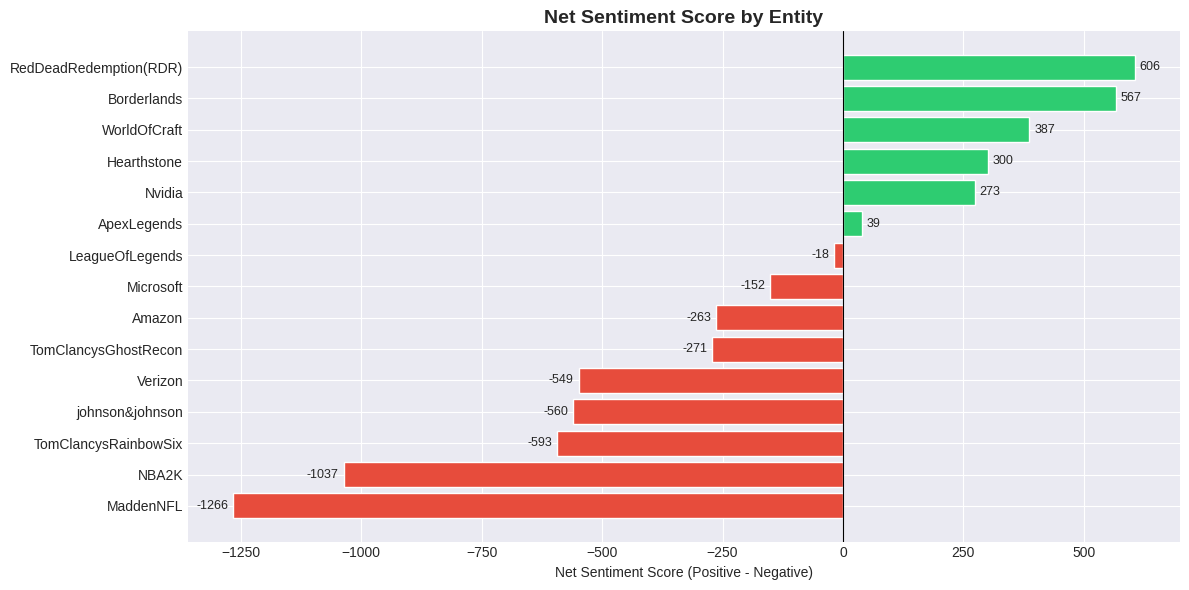

In [ ]:
top15 = train_df['Entity'].value_counts().head(15).index
subset = train_df[train_df['Entity'].isin(top15)]
counts = subset.groupby(['Entity','Sentiment']).size().unstack(fill_value=0)
counts['Net_Score'] = counts.get('Positive',0) - counts.get('Negative',0)
counts = counts.sort_values('Net_Score')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in counts['Net_Score']]
bars = ax.barh(counts.index, counts['Net_Score'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Net Sentiment Score (Positive - Negative)')
ax.set_title('Net Sentiment Score by Entity', fontsize=14, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + (10 if w >= 0 else -10), bar.get_y() + bar.get_height()/2.,
            f'{int(w)}', va='center', ha='left' if w >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('net_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predict Sentiment on Custom Tweets

In [ ]:
best_model = results[best_name]['model']

sample_tweets = [
    'I absolutely love this game! Best experience ever!',
    'This is the worst update, everything is broken and laggy',
    'Just downloaded the new version, checking it out now',
    'The graphics are stunning and gameplay is smooth',
    'Cannot believe how terrible the customer support is',
    'New patch released today for all platforms',
    'This is amazing!! Best purchase I have ever made',
    'Hate this trash, waste of money honestly',
    'Anyone else playing this weekend? Let me know'
]

cleaned = [clean_text(t) for t in sample_tweets]
vectorized = tfidf.transform(cleaned)
predictions = best_model.predict(vectorized)

emoji_map = {'Positive': 'POS', 'Negative': 'NEG', 'Neutral': 'NEU'}

print('=' * 70)
print('CUSTOM TWEET PREDICTIONS')
print('=' * 70)
for tweet, pred in zip(sample_tweets, predictions):
    print(f'\n[{pred:>8}]  {tweet}')
print('\n' + '=' * 70)

CUSTOM TWEET PREDICTIONS

[Positive]  I absolutely love this game! Best experience ever!

[Negative]  This is the worst update, everything is broken and laggy

[Positive]  Just downloaded the new version, checking it out now

[Positive]  The graphics are stunning and gameplay is smooth

[Negative]  Cannot believe how terrible the customer support is

[Positive]  New patch released today for all platforms

[Positive]  This is amazing!! Best purchase I have ever made

[Negative]  Hate this trash, waste of money honestly

[Negative]  Anyone else playing this weekend? Let me know



## 8. Summary

### Model Performance
- Multiple ML models were trained and compared on the Twitter sentiment dataset
- **TF-IDF** with bigrams was used for feature extraction
- The best model achieved strong accuracy on the validation set

### Public Opinion Insights
- Sentiment varies significantly across different entities/brands
- Some entities have overwhelmingly positive reception while others trend negative
- Net sentiment scores reveal which brands/topics have the most favorable public opinion

### Visualizations Created
| Chart | Description |
|-------|-------------|
| Sentiment Distribution | Class balance across train/val sets |
| Word Clouds | Most frequent words per sentiment |
| Top Words | Bar charts of top 15 words per class |
| Model Comparison | Accuracy across 4 ML algorithms |
| Confusion Matrix | Detailed error analysis of best model |
| Opinion Trends | Sentiment counts across top entities |
| Sentiment Heatmap | Percentage breakdown per entity |
| Net Sentiment Score | Positive vs Negative gap per entity |